In [1]:
import aopy
from aopy.data import db
from aopy.analysis import accllr
import os
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import h5py
import traceback
from scipy.stats import zscore
import datetime
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

from aopy.visualization import annotate_spatial_map_channels
from aopy.data.bmi3d import tabulate_ts_data
from aopy.preproc.bmi3d import get_laser_trial_times
from aopy.preproc.quality import detect_bad_trials

from aopy.analysis.connectivity import get_acq_ch_near_stimulation_site
from aopy.visualization import plot_xy_scalebar, overlay_sulci_on_spatial_map
from aopy.visualization import plot_annotated_spatial_drive_map_stim, plot_annotated_stim_drive_data
from aopy.analysis import calc_fdrc_ranktest

data_dir = '/media/moor-data/raw'
preproc_dir = '/data/preprocessed'
postproc_dir = '/data/postprocessed/leo'
fig_dir = './figures'

version = 'v251017'


/home/aolab/miniconda3/envs/leo-analysis/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
sns.set_theme('paper', font_scale=1, font="Arial", rc={
    'svg.fonttype': 'none',
    "font.size" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [3]:
from connectivity_analysis import *
from connectivity_plotting import *

In [4]:
elec_pos, acq_ch, elecs = aopy.data.load_chmap()

## Load data

In [5]:
a_rest_df = load_df(postproc_dir, 'affi', 'rest', version)
b_rest_df = load_df(postproc_dir, 'beignet', 'rest', version)
a_null_df = load_df(postproc_dir, 'affi', 'rest_null', version)
b_null_df = load_df(postproc_dir, 'beignet', 'rest_null', version)

  0%|          | 0/32 [00:00<?, ?it/s]

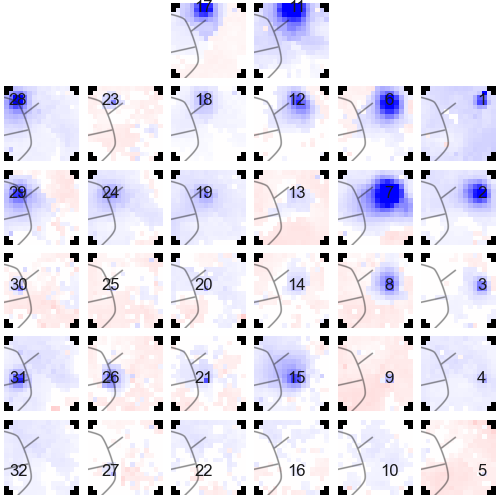

  0%|          | 0/32 [00:00<?, ?it/s]

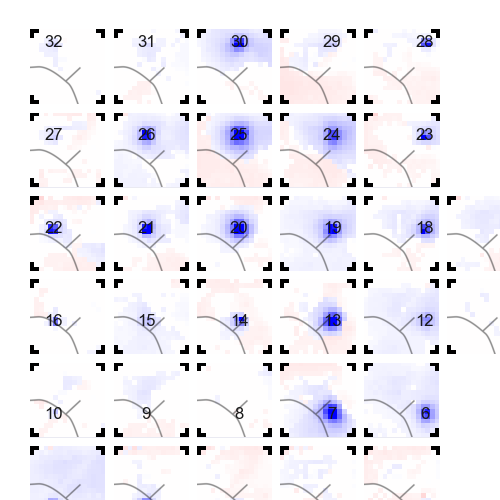

In [6]:
alpha = 0.01
for subject in ['beignet', 'affi']:
    
    subj_data = aopy.data.pkl_read(
        f'{subject}_connectivity_all_sites_{version}.pkl', postproc_dir)
    theta = 0 if subject == 'beignet' else 90
    stim_ch = subj_data['sites']
    
    elec_pos, acq_ch, elecs = aopy.data.load_chmap(theta=theta)
    fig1, ax_data = place_Opto32_subplots(theta=theta)

    for idx, stim_site in enumerate(tqdm(stim_ch)):

        diff, p = calc_fdrc_ranktest(subj_data['erp_map'][idx], subj_data['erp_null_maps'][idx], 
                                     alternative='two-sided', alpha=alpha)
        scaled = scale_data_by_p_value(diff, p)
                
        # Plot the data
        plot_annotated_spatial_drive_map_stim(scaled, stim_site, subject, 'lm1', theta, 
                                              cmap='bwr', clim=(-3,3), interp_method='cubic', 
                                              colorbar=False, color='k', ax=ax_data[idx])        
    filename = f"opto_response_all_{subject}.svg"
    aopy.visualization.savefig(fig_dir, filename)
    plt.show()



## Plot examples

In [7]:
b_all_sites = aopy.data.pkl_read(
    f'beignet_connectivity_all_sites_{version}.pkl', postproc_dir)
a_all_sites = aopy.data.pkl_read(
    f'affi_connectivity_all_sites_{version}.pkl', postproc_dir)

In [8]:
# Example ERP
stim_site = 12
subject = 'beignet'
theta = 0

time_before = 0.25
time_after = 0.25
altcond_window = (-0.01, 0.05)
nullcond_window = (-time_before, 0)

df = b_rest_df[b_rest_df['stimulation_site'].astype(int) == stim_site].reset_index()
bad_trials = get_bad_stim_trials(df, time_before, time_after, channels=acq_ch-1)
df = df[~bad_trials].reset_index()

erp, samplerate = load_stim_erp(df, time_before, time_after, channels=acq_ch-1)

altcond, nullcond = aopy.analysis.latency.prepare_erp(erp, erp, samplerate, 
                                                      time_before, time_after, 
                                                      nullcond_window, altcond_window)[:2]

# Max ERP
z_erp = np.std(nullcond, axis=0)
sd_erp = (altcond - np.mean(nullcond, axis=0)) / z_erp
max_erp = aopy.analysis.get_max_erp(sd_erp, 0, time_after, samplerate, trial_average=True)

ch_stim = 39
ch_near = 54
ch_far = 127
idx_stim = np.where(acq_ch == ch_stim)[0][0]
idx_near = np.where(acq_ch == ch_near)[0][0]
idx_far = np.where(acq_ch == ch_far)[0][0]

# Single trial ERP
erp_trials = sd_erp[:,idx_stim,:]
erp_surround = sd_erp[:,idx_near,:]
erp_control = sd_erp[:,idx_far,:]

In [9]:
# Latency
altcond_window_accllr = (0, 0.06)
nullcond_window_accllr = (-0.06, 0)
altcond, nullcond = aopy.analysis.latency.prepare_erp(erp, erp, samplerate, 
                                                      time_before, time_after, 
                                                      nullcond_window_accllr, altcond_window_accllr)[:2]

st, auc, se, p = aopy.analysis.latency.calc_accllr_st(
    altcond, nullcond, 
    altcond, nullcond,
    'lfp', 1./samplerate, nlevels=None, match_selectivity=False, 
    match_ch=None, noise_sd_step=5, parallel=True
)

latency = np.nanmedian(st, axis=1)
latency_trials = st[idx_stim,:]
latency_surround = st[idx_near,:]
latency_control = st[idx_far,:]

  0%|          | 0/240 [00:00<?, ?it/s]

/tmp/ipykernel_2724236/908681979.py:15: RuntimeWarning: All-NaN slice encountered
  latency = np.nanmedian(st, axis=1)


In [10]:
# AUC Monkey 1
b_volume, p = calc_volume(b_all_sites['erp_map'], b_all_sites['erp_null_maps'], alpha=alpha)
b_volume[p > alpha] = np.nan

# AUC Monkey 2
a_volume, p = calc_volume(a_all_sites['erp_map'], a_all_sites['erp_null_maps'], alpha=alpha)
a_volume[p > alpha] = np.nan

In [11]:
def plot_electrode_selection(selected_idx, unselected_idx, elec_pos, color='black', 
                             ax=None, **kwargs):
    """
    Draws boxes around selected electrodes at the given electrode positions.

    Parameters:

    - channels_pos: numpy array of shape (n_channels, 2) with the positions of the electrodes.
    - selected_electrodes: list or array of indices of the selected electrodes.
    - ax: matplotlib axes object where the plot will be drawn. If None, a new figure and axes will be created.
    """
    if ax is None:
        ax = plt.gca()
        
    # Plot the selected electrodes using a solid square
    ax.plot(elec_pos[selected_idx, 0], 
            elec_pos[selected_idx, 1], "s", 
            c=color,
            **kwargs)

    # Plot the unselected electrodes using a hollow square
    ax.plot(elec_pos[unselected_idx, 0], 
            elec_pos[unselected_idx, 1], "s",
            c=color,
            markerfacecolor='none',
            markeredgecolor=color,
            **kwargs)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')

    # Remove the plot boundary
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Remove the x and y scale markers
    ax.set_xticks([])
    ax.set_yticks([])


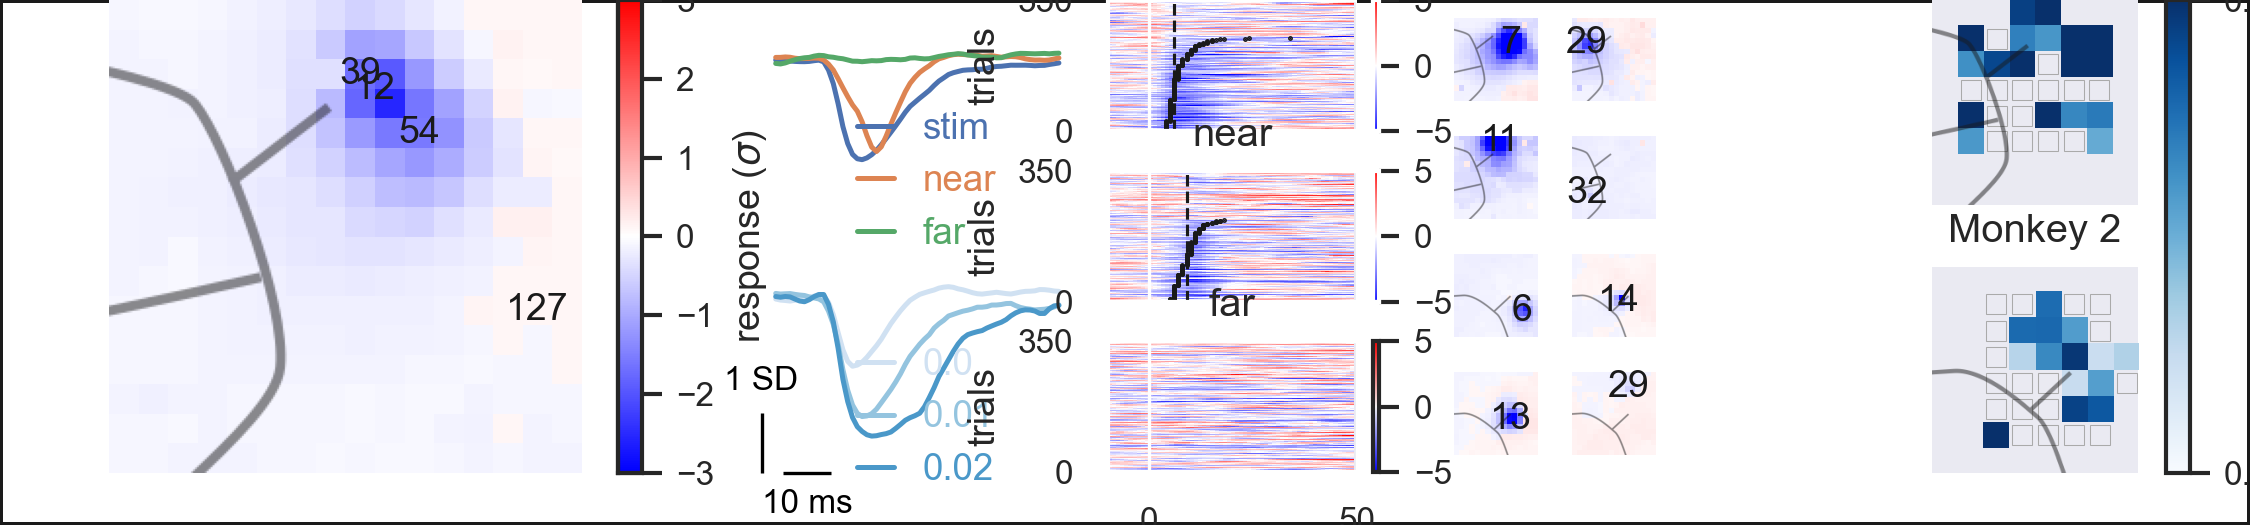

In [13]:
# Figure 1 plots

fig = plt.figure(figsize=(7.5, 1.75), dpi=300, edgecolor='k', linewidth=1)
wr = [0.35, 0.15, 0.15, 0.04, 0.04, 0.27]
grid2 = GridSpec(2, 6, width_ratios=wr, wspace=0.1, hspace=0.3)
grid3 = GridSpec(3, 6, width_ratios=wr, wspace=0.1, hspace=0.3)
grid4 = GridSpec(4, 6, width_ratios=wr, wspace=0.1, hspace=0.0)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)

sns.set_style('ticks') 
ax = fig.add_subplot(grid2[:,0])
im, pcm = plot_annotated_spatial_drive_map_stim(max_erp, stim_site, df['subject'][0], 'lm1', 0, 
                                           grid_size=(16,16), cmap='bwr', clim=(-3,3),
                                           colorbar=True, fontsize=9, color='k')
aopy.visualization.annotate_spatial_map_channels(acq_ch=[ch_stim, ch_near, ch_far],
                                                 color='k', fontsize=9)        
pcm.set_label('response ($\\sigma$)')
plt.axis('off')

# Sweep recording electrode
sns.set_style('darkgrid') 
ax = fig.add_subplot(grid4[:2,1])

aopy.visualization.plot_timeseries(np.mean(erp_trials, axis=1), samplerate)
aopy.visualization.plot_timeseries(np.mean(erp_surround, axis=1), samplerate)
aopy.visualization.plot_timeseries(np.mean(erp_control, axis=1), samplerate)
plt.ylim(-3,1)
plt.legend(['stim', 'near', 'far'], bbox_to_anchor=(0.2,-0.2), loc='lower left', 
           labelcolor='linecolor', handlelength=1, frameon=False)
plt.axis('off')

# Sweep pulse width
ax = fig.add_subplot(grid4[2:,1])
colors = sns.color_palette('Blues', n_colors=4)
ax.set_prop_cycle(plt.cycler(color=colors))
width = np.round(df['trial_width'], 2)
widths = np.unique(width)
for w in widths:
    aopy.visualization.plot_timeseries(np.mean(erp_trials[:,width==w], axis=1), samplerate)
plt.ylim(-3,1)
plt.legend(widths, bbox_to_anchor=(0.2,-0.2), loc='lower left', 
           labelcolor='linecolor', handlelength=1, frameon=False)
plt.axis('off')
plot_xy_scalebar(plt.gca(), 0.01, '10 ms', 1, '1 SD', color='black', fontsize=8,
                bbox_to_anchor=[0.,0.])


# Single trial response
ax = fig.add_subplot(grid3[0,2])
im = plot_stim_erp_time(erp_trials, -altcond_window[0], altcond_window[1], samplerate, stim_site, 
                   df['subject'][0], theta=0, clim=(-5,5), latency=latency_trials)
plt.xticks([0,50], labels=[])
sns.despine()
plt.colorbar(im)
plt.title('stim')
ax = fig.add_subplot(grid3[1,2])
im = plot_stim_erp_time(erp_surround, -altcond_window[0], altcond_window[1], samplerate, stim_site, 
                   df['subject'][0], theta=0, clim=(-5,5), latency=latency_surround)
plt.xticks([0,50], labels=[])
sns.despine()
tmp = plt.colorbar(im)
plt.title('near')
ax = fig.add_subplot(grid3[2,2])
im = plot_stim_erp_time(erp_control, -altcond_window[0], altcond_window[1], samplerate, stim_site, 
                        df['subject'][0], theta=0, clim=(-5,5))
plt.xlabel('time (ms)')
sns.despine()
sns.set_style('ticks') 
pcm = plt.colorbar(im)
pcm.set_label('$\\sigma$')
plt.title('far')


# Example big response sites
sns.set_style('ticks') 
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [7, 11, 6, 13])):
    
    ax = fig.add_subplot(grid4[idx,3]).axis('off')
    
    subj_connectivity = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    max_erp_ = subj_connectivity['erp_map'][stim_site_-1]
    im = plot_annotated_spatial_drive_map_stim(max_erp_, stim_site_, subject_, 'lm1', theta_, 
                                               grid_size=(16,16), cmap='bwr', clim=(-3,3),
                                               colorbar=False, fontsize=9, color='k')

# Example small response sites
for idx, (subject_, theta_, stim_site_) in enumerate(zip(
    ['beignet', 'beignet', 'affi', 'affi'], [0, 0, 90, 90], [29, 32, 14, 29])):
    
    ax = fig.add_subplot(grid4[idx,4]).axis('off')
    
    subj_connectivity = aopy.data.pkl_read(
        f'{subject_}_connectivity_all_sites_{version}.pkl', postproc_dir)
    max_erp_ = subj_connectivity['erp_map'][stim_site_-1]
    im = plot_annotated_spatial_drive_map_stim(max_erp_, stim_site_, subject_, 'lm1', theta_, 
                                               grid_size=(16,16), cmap='bwr', clim=(-3,3),
                                               colorbar=False, fontsize=9, color='k')

# Plot significant AUC
# Monkey 1
ax1 = fig.add_subplot(grid2[0,5])
ax1.set_facecolor('#EAEAF2')
stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=0)
plot_electrode_selection([], range(32), stim_pos, color='#AAAAAA', zorder=-1, markeredgewidth=0.25)
im, pcm = plot_annotated_stim_drive_data(b_volume, 'beignet', 'lm1', 0, cmap='Blues', nan_color="#00000000",
                                        colorbar=False)
im.set_clim(0,0.2)
plt.gca().set(xticks=[], yticks=[], xlabel='', ylabel='')
plt.title('Monkey 1')

# Monkey 2
ax2 = fig.add_subplot(grid2[1,5])
ax2.set_facecolor('#EAEAF2')
stim_pos, _, stim_ch = aopy.data.load_chmap('Opto32', theta=90)
plot_electrode_selection([], range(32), stim_pos, color='#AAAAAA', zorder=-1, markeredgewidth=0.25)
im, pcm = plot_annotated_stim_drive_data(a_volume, 'affi', 'lm1', 90, cmap='Blues', nan_color="#00000000",
                                        colorbar=False)
im.set_clim(0,0.2)
plt.gca().set(xticks=[], yticks=[], xlabel='', ylabel='')
plt.title('Monkey 2')

pcm = plt.colorbar(im, ax=[ax1, ax2])
pcm.set_ticks([0,0.2])
pcm.set_label('mean response ($\\sigma$)')

filename = f"opto_summary.svg"
aopy.visualization.savefig(fig_dir, filename)